# HOUSE PRICE PREDICTION PROJECT

In [6]:
import pandas as pd

In [7]:
import numpy as np 

In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns 


In [10]:
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
df = pd.read_csv("House Price Prediction Dataset.csv")

df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [12]:
df.tail(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1990,1991,4827,4,4,1,1959,Suburban,Fair,Yes,834141
1991,1992,4397,4,1,2,1981,Rural,Poor,Yes,847822
1992,1993,2450,1,3,3,2006,Urban,Good,Yes,225508
1993,1994,865,4,4,2,2020,Rural,Poor,No,308446
1994,1995,2174,1,1,2,1973,Downtown,Poor,No,527698
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [15]:
df. describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [16]:
df.shape

(2000, 10)

In [17]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

### CORRELATION HEAT MAP (EDA)

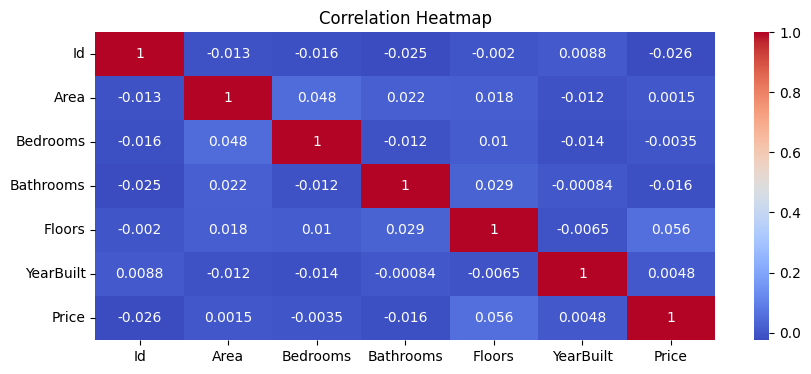

In [27]:
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()           

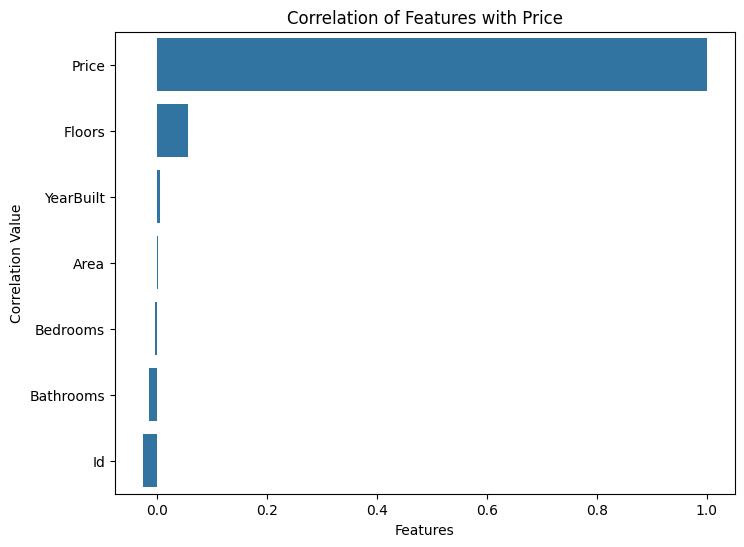

In [20]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)
sns.barplot(x=corr.values, y=corr.index)
plt.title('Correlation of Features with Price')
plt.xlabel('Features')
plt.ylabel('Correlation Value')
plt.show()

In [30]:
x = df.drop("Price", axis=1)
y = df["Price"]

TRAIN- TEST SPILT

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
x, y, test_size=0.2,random_state=42
)

## MODEL TRAINING

In [41]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## CREATE MODEL DICTIONANY

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
    }

## TRAIN+EVALUATE ALL MODELS

In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply ONLY to categorical columns
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [60]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(results_df)

               Model            MAE           RMSE  R2 Score
7                SVR  242647.175359  279110.278025 -0.001333
1              Ridge  244002.058528  280468.013484 -0.011099
2              Lasso  244003.300502  280469.544508 -0.011110
0  Linear Regression  244003.463898  280469.738028 -0.011111
5  Gradient Boosting  245032.718740  284839.044071 -0.042860
4      Random Forest  250333.305650  289228.639487 -0.075250
8                KNN  254630.962500  300866.257818 -0.163520
6        Extra Trees  258941.430600  303758.659538 -0.185999
3      Decision Tree  335943.895000  409988.261268 -1.160577


### PICK BEST MODEL

In [65]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest Model is: {best_model_name}")


Best Model is: SVR


## SAVE BEST MODEL

In [69]:
import os
import pickle

print("Current working directory:", os.getcwd())
file_path = os.path.join(os.getcwd(), 'best_model.pkl')
with open(file_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Best model saved to: {file_path}")

Current working directory: c:\Users\Administrator\Downloads\python folder\house prediction
Best model saved to: c:\Users\Administrator\Downloads\python folder\house prediction\best_model.pkl
